In [1]:
Data loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("healthcare_messy_data.csv")

In [3]:
df.head()

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,


In [4]:
Data shape checking

(1000, 10)

In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['Patient Name', 'Age', 'Gender', 'Condition', 'Medication',
       'Visit Date', 'Blood Pressure', 'Cholesterol', 'Email', 'Phone Number'],
      dtype='str')

In [6]:
df.dtypes

Patient Name          str
Age                   str
Gender                str
Condition             str
Medication            str
Visit Date            str
Blood Pressure        str
Cholesterol       float64
Email                 str
Phone Number          str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient Name    1000 non-null   str    
 1   Age             841 non-null    str    
 2   Gender          1000 non-null   str    
 3   Condition       794 non-null    str    
 4   Medication      1000 non-null   str    
 5   Visit Date      1000 non-null   str    
 6   Blood Pressure  834 non-null    str    
 7   Cholesterol     769 non-null    float64
 8   Email           616 non-null    str    
 9   Phone Number    821 non-null    str    
dtypes: float64(1), str(9)
memory usage: 78.3 KB


In [ ]:
Data Quality Assessment

In [8]:
df.isnull().sum()

Patient Name        0
Age               159
Gender              0
Condition         206
Medication          0
Visit Date          0
Blood Pressure    166
Cholesterol       231
Email             384
Phone Number      179
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100

Patient Name       0.0
Age               15.9
Gender             0.0
Condition         20.6
Medication         0.0
Visit Date         0.0
Blood Pressure    16.6
Cholesterol       23.1
Email             38.4
Phone Number      17.9
dtype: float64

In [10]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Count,Missing Percentage
Patient Name,0,0.0
Age,159,15.9
Gender,0,0.0
Condition,206,20.6
Medication,0,0.0
Visit Date,0,0.0
Blood Pressure,166,16.6
Cholesterol,231,23.1
Email,384,38.4
Phone Number,179,17.9


In [ ]:
Check hidden missing values

In [11]:
(df.astype(str).apply(lambda col: col.str.strip() == "")).sum()

Patient Name        0
Age                 0
Gender              0
Condition           0
Medication          0
Visit Date          0
Blood Pressure      0
Cholesterol         0
Email               0
Phone Number      200
dtype: int64

In [12]:
placeholders = ["Unknown", "N/A", "NULL"]

for value in placeholders:
    print(f"\nOccurrences of '{value}':")
    print((df == value).sum())


Occurrences of 'Unknown':
Patient Name      0
Age               0
Gender            0
Condition         0
Medication        0
Visit Date        0
Blood Pressure    0
Cholesterol       0
Email             0
Phone Number      0
dtype: int64

Occurrences of 'N/A':
Patient Name      0
Age               0
Gender            0
Condition         0
Medication        0
Visit Date        0
Blood Pressure    0
Cholesterol       0
Email             0
Phone Number      0
dtype: int64

Occurrences of 'NULL':
Patient Name      0
Age               0
Gender            0
Condition         0
Medication        0
Visit Date        0
Blood Pressure    0
Cholesterol       0
Email             0
Phone Number      0
dtype: int64


In [13]:
for column in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(df[column].unique())


Column: Patient Name
<StringArray>
[     ' david lee ',    ' emily davis ', ' laura martinez ',
 ' michael wilson ',     ' mary clark ',   ' robert brown ',
  ' sarah johnson ',     ' jane smith ',       ' john doe ',
   ' james taylor ']
Length: 10, dtype: str

Column: Age
<StringArray>
['25', nan, '35', '60', 'forty', '70']
Length: 6, dtype: str

Column: Gender
<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str

Column: Condition
<StringArray>
['Heart Disease', 'Diabetes', 'Asthma', 'Hypertension', nan]
Length: 5, dtype: str

Column: Medication
<StringArray>
['METFORMIN', 'NONE', 'ALBUTEROL', 'LISINOPRIL', 'ATORVASTATIN']
Length: 5, dtype: str

Column: Visit Date
<StringArray>
['01/15/2020', 'April 5, 2018', '2019.12.01', '2020/02/20', '03-25-2019']
Length: 5, dtype: str

Column: Blood Pressure
<StringArray>
['140/90', '120/80', '110/70', nan, '130/85']
Length: 5, dtype: str

Column: Cholesterol
[200. 160.  nan 180. 220.]

Column: Email
<StringArray>
['name@hospital.org

In [14]:
df["Age"].value_counts(dropna=False)

Age
forty    176
25       171
60       170
35       163
70       161
NaN      159
Name: count, dtype: int64

In [15]:
df["Age"] = df["Age"].replace({
    "forty": 40
})

In [16]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

In [17]:
df["Age"].dtype

dtype('float64')

In [ ]:
Remove Leading and Trailing Spaces from All Text Columns


In [18]:
text_columns = df.select_dtypes(include=["object", "string"]).columns

df[text_columns] = df[text_columns].apply(lambda col: col.str.strip())

In [19]:
df["Patient Name"].unique()

<StringArray>
[     'david lee',    'emily davis', 'laura martinez', 'michael wilson',
     'mary clark',   'robert brown',  'sarah johnson',     'jane smith',
       'john doe',   'james taylor']
Length: 10, dtype: str

In [ ]:
Convert Visit Date to Datetime

In [20]:
df["Visit Date"] = pd.to_datetime(df["Visit Date"], errors="coerce")

In [21]:
df["Visit Date"].dtype

dtype('<M8[us]')

In [22]:
df["Visit Date"].head()

0   2020-01-15
1          NaT
2          NaT
3   2020-01-15
4          NaT
Name: Visit Date, dtype: datetime64[us]

In [23]:
df = pd.read_csv("healthcare_messy_data.csv")

In [24]:

df["Age"] = df["Age"].replace({"forty": 40})
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")


text_columns = df.select_dtypes(include=["object", "string"]).columns
df[text_columns] = df[text_columns].apply(lambda col: col.str.strip())

In [25]:
df["Visit Date"] = pd.to_datetime(
    df["Visit Date"],
    format="mixed",
    errors="coerce"
)

In [26]:
df["Visit Date"].head()

0   2020-01-15
1   2018-04-05
2   2019-12-01
3   2020-01-15
4   2020-02-20
Name: Visit Date, dtype: datetime64[us]

In [27]:
df["Visit Date"].isnull().sum()

np.int64(0)

In [28]:
df.isnull().sum()

Patient Name        0
Age               159
Gender              0
Condition         206
Medication          0
Visit Date          0
Blood Pressure    166
Cholesterol       231
Email             384
Phone Number      179
dtype: int64

In [29]:
df["Age"].describe()

count    841.000000
mean      45.766944
std       16.456303
min       25.000000
25%       35.000000
50%       40.000000
75%       60.000000
max       70.000000
Name: Age, dtype: float64

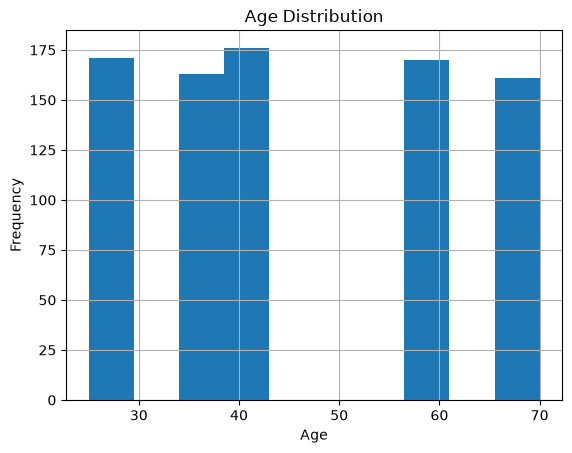

In [30]:
import matplotlib.pyplot as plt

df["Age"].hist(bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [31]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [32]:
df["Age"].isnull().sum()

np.int64(0)

In [33]:
df["Condition"].value_counts(dropna=False)

Condition
Asthma           211
Heart Disease    207
NaN              206
Diabetes         205
Hypertension     171
Name: count, dtype: int64

In [34]:
df["Condition"].mode()

0    Asthma
Name: Condition, dtype: str

In [35]:
df["Condition"] = df["Condition"].fillna(df["Condition"].mode()[0])

In [36]:
df["Condition"].isnull().sum()

np.int64(0)

In [37]:
df["Blood Pressure"].value_counts(dropna=False)

Blood Pressure
140/90    233
110/70    211
120/80    197
130/85    193
NaN       166
Name: count, dtype: int64

In [38]:
df["Blood Pressure"].mode()

0    140/90
Name: Blood Pressure, dtype: str

In [39]:
df["Blood Pressure"] = df["Blood Pressure"].fillna(
    df["Blood Pressure"].mode()[0]
)

In [40]:
df["Blood Pressure"].isnull().sum()

np.int64(0)

In [41]:
df["Cholesterol"].describe()

count    769.00000
mean     189.23277
std       22.28039
min      160.00000
25%      160.00000
50%      180.00000
75%      200.00000
max      220.00000
Name: Cholesterol, dtype: float64

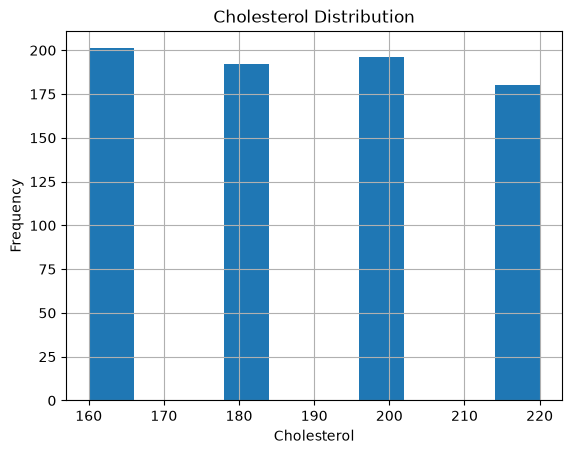

In [42]:
import matplotlib.pyplot as plt

df["Cholesterol"].hist(bins=10)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

In [43]:
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

In [44]:
df["Cholesterol"].isnull().sum()

np.int64(0)

In [45]:
df["Email"].value_counts(dropna=False)

Email
NaN                    384
contact@domain.com     217
patient@example.com    203
name@hospital.org      196
Name: count, dtype: int64

In [46]:
df["Phone Number"].value_counts(dropna=False)

Phone Number
123-456-7890    245
                200
555-555-5555    193
098-765-4321    183
NaN             179
Name: count, dtype: int64

In [ ]:
Dealing with duplicate records

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df[df.duplicated()]

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number


In [49]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

age_outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]

age_outliers

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number


In [50]:
len(age_outliers)

0

In [51]:
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

cholesterol_outliers = df[
    (df["Cholesterol"] < lower_bound) |
    (df["Cholesterol"] > upper_bound)
]

cholesterol_outliers

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number


In [52]:
len(cholesterol_outliers)

0

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Patient Name    1000 non-null   str           
 1   Age             1000 non-null   float64       
 2   Gender          1000 non-null   str           
 3   Condition       1000 non-null   str           
 4   Medication      1000 non-null   str           
 5   Visit Date      1000 non-null   datetime64[us]
 6   Blood Pressure  1000 non-null   str           
 7   Cholesterol     1000 non-null   float64       
 8   Email           616 non-null    str           
 9   Phone Number    821 non-null    str           
dtypes: datetime64[us](1), float64(2), str(7)
memory usage: 78.3 KB


In [61]:
df.to_csv("cleaned.csv", index=False)

In [56]:
df.head()

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25.0,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,40.0,Male,Diabetes,NONE,2018-04-05,120/80,200.0,NaN,NaN
2,laura martinez,35.0,Other,Asthma,METFORMIN,2019-12-01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,40.0,Male,Diabetes,ALBUTEROL,2020-01-15,110/70,180.0,name@hospital.org,555-555-5555
4,david lee,40.0,Female,Asthma,NONE,2020-02-20,110/70,180.0,NaN,


In [57]:
df.tail()

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
995,mary clark,70.0,Other,Asthma,ALBUTEROL,2019-03-25,110/70,180.0,name@hospital.org,NaN
996,mary clark,40.0,Other,Asthma,LISINOPRIL,2020-01-15,140/90,160.0,NaN,123-456-7890
997,laura martinez,40.0,Other,Asthma,ALBUTEROL,2020-02-20,110/70,180.0,name@hospital.org,NaN
998,jane smith,25.0,Male,Asthma,ALBUTEROL,2018-04-05,110/70,200.0,NaN,
999,james taylor,40.0,Male,Diabetes,ATORVASTATIN,2020-02-20,120/80,220.0,NaN,123-456-7890


In [ ]:
PLOTS

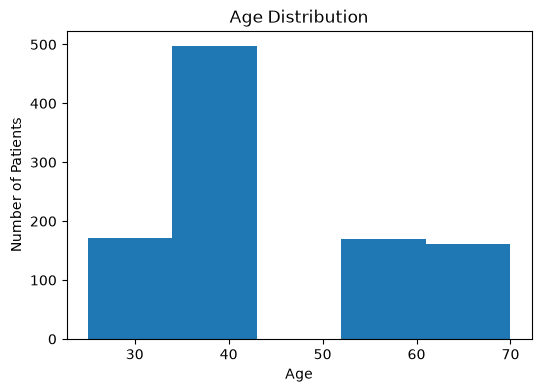

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=5)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

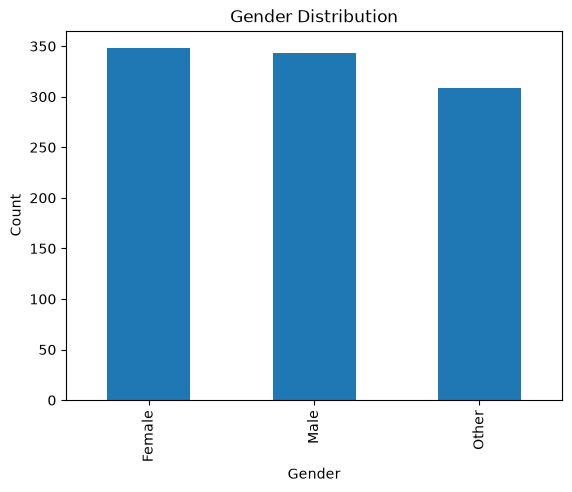

In [63]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

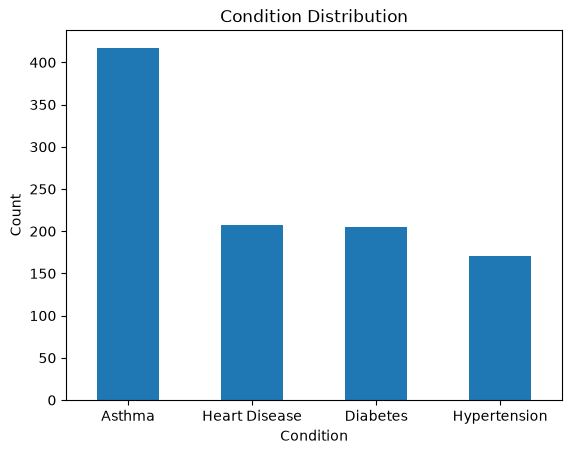

In [64]:
df["Condition"].value_counts().plot(kind="bar")

plt.title("Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

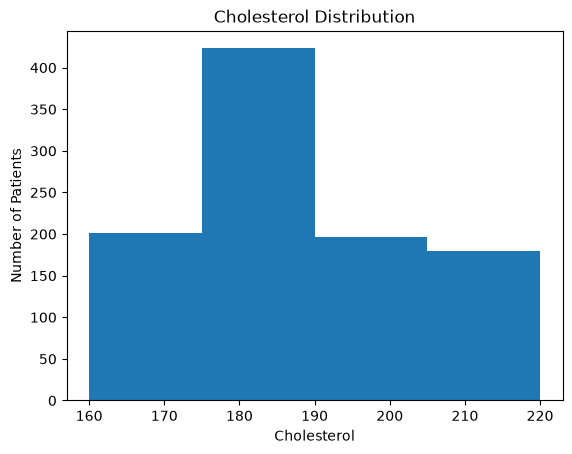

In [65]:
plt.hist(df["Cholesterol"], bins=4)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

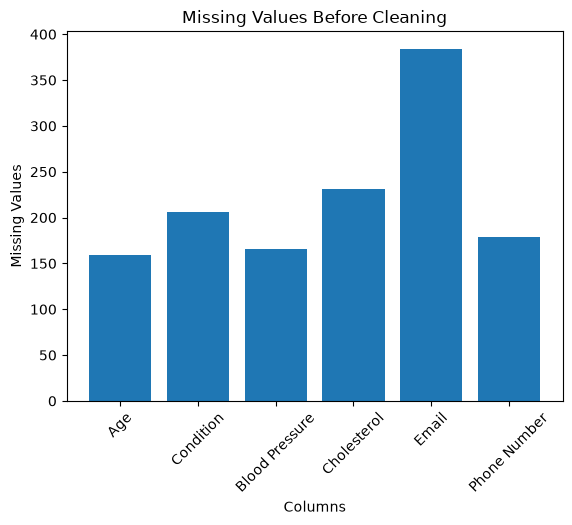

In [66]:
missing = {
    "Age":159,
    "Condition":206,
    "Blood Pressure":166,
    "Cholesterol":231,
    "Email":384,
    "Phone Number":179
}

plt.bar(missing.keys(), missing.values())

plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Missing Values")

plt.xticks(rotation=45)

plt.show()

In [67]:
df["Age"] = df["Age"].astype(int)
df["Cholesterol"] = df["Cholesterol"].astype(int)

In [68]:
df.to_csv("cleaned.csv", index=False)